Will eventually add things here (have added things here)

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from knnbench.datasets import load_breast_cancer_df, load_adult_df, preprocess_adult_df, transform_adult_df
from knnbench.utils import compute_metrics, set_seed

Below is test on the breast cancer dataset

In [3]:
from experiments.manual_knn import ManualKNNClassifier

set_seed()

X, y = load_breast_cancer_df()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\nManual KNN with uniform voting:")
knn = ManualKNNClassifier(k=5, voting="uniform").fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

print("\nManual KNN with distance voting:")
knn = ManualKNNClassifier(k=5, voting="distance").fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")


Manual KNN with uniform voting:
accuracy: 0.9561
macro_recall: 0.9504
macro_f1: 0.9526
precision_0: 0.9512
recall_0: 0.9286
f1_0: 0.9398
precision_1: 0.9589
recall_1: 0.9722
f1_1: 0.9655

Manual KNN with distance voting:
accuracy: 0.9561
macro_recall: 0.9504
macro_f1: 0.9526
precision_0: 0.9512
recall_0: 0.9286
f1_0: 0.9398
precision_1: 0.9589
recall_1: 0.9722
f1_1: 0.9655


Below is test on the adult set


Manual KNN with uniform voting:
{'accuracy': 0.8331456648582249, 'macro_recall': 0.7537189304417866, 'macro_f1': 0.7625362769077841}


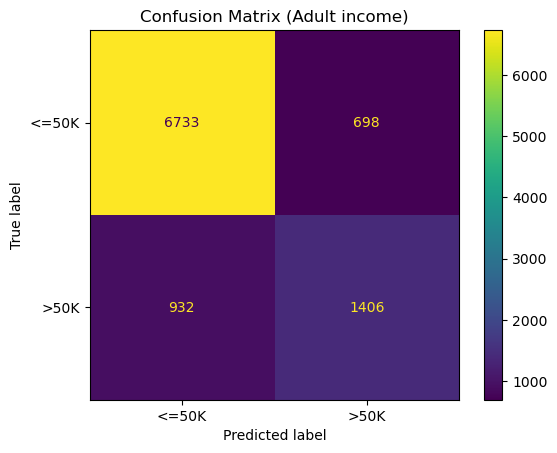


Manual KNN with distance voting:
{'accuracy': 0.8309960077797113, 'macro_recall': 0.7512799247229056, 'macro_f1': 0.759743957784248}


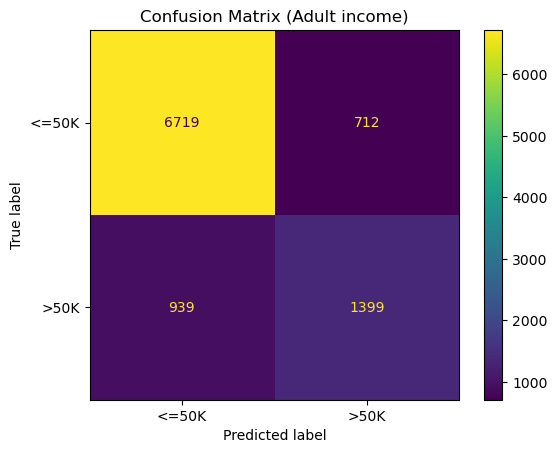

In [ ]:
from experiments.manual_knn import ManualKNNClassifier

seed = 42
set_seed(seed)

X, y = load_adult_df()

# X, _, y, _ = train_test_split(
#     X, y, train_size=10000, random_state=seed, stratify=y
# )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_proc, prep = preprocess_adult_df(X_train, scaling="standard", return_preprocessor=True)
X_test_proc = transform_adult_df(X_test, prep)

print("\nManual KNN with uniform voting:")
knn = ManualKNNClassifier(k=5, voting="uniform").fit(X_train_proc, y_train)

y_pred = knn.predict(X_test_proc)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

labels = ["<=50K", ">50K"] 
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Adult income)")
plt.show()

print("\nManual KNN with distance voting:")
knn = ManualKNNClassifier(k=5, voting="distance").fit(X_train_proc, y_train)

y_pred = knn.predict(X_test_proc, 512)

metrics = compute_metrics(y_test, y_pred)
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

labels = ["<=50K", ">50K"] 
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Adult income)")
plt.show()

Below was for resetting the manualKNNclassifier class because vscode was straight tripping out and lying to me, also got a 30x speed boost out of it

In [45]:
import importlib
import experiments.manual_knn as manual_knn
importlib.reload(manual_knn)

ManualKNNClassifier = manual_knn.ManualKNNClassifier
